# Phase 2.3 — Transformer-Based Misinformation Classifiers

**Goal:** Train and evaluate transformer-based classifiers using SBERT embeddings and optional DistilBERT fine-tuning.

## Approach
1. **SBERT embeddings** (`all-MiniLM-L6-v2`) + sklearn classifiers (LR, SVM, MLP)
   - Fast, interpretable, strong baseline
2. **DistilBERT fine-tuning** (optional, leverages GPU if available)
   - End-to-end fine-tuning for sequence classification

Both approaches auto-detect GPU; designed to run on CPU for reproducibility.

In [1]:
import sys
import warnings
import json
import time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

MODEL_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Device detection
try:
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
except ImportError:
    DEVICE = 'cpu'

print(f'Device: {DEVICE}')
print('✓ Setup complete')

Device: cpu
✓ Setup complete


## 2. Data Loading

Loads via the unified pipeline (FakeNewsNet). Falls back to synthetic demo data if pipeline data is unavailable.

In [2]:
# ── Load real FakeNewsNet data ────────────────────────────────────────────
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[2] if "__file__" in dir() else pathlib.Path.cwd()))
import subprocess, os
_root = pathlib.Path(subprocess.run(["git","rev-parse","--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, str(_root))
from src.real_data_loader import load_articles_df, load_splits

df = load_articles_df()
# rename 'title' → 'text' for notebook compatibility
df['text'] = df['title']

train_df, val_df = load_splits()
train_df['text'] = train_df['title']
val_df['text']   = val_df['title']

print(f"Dataset: {len(df):,} articles  |  fake={df['label_num'].mean():.1%}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")


Dataset: 21,724 articles  |  fake=23.9%
Train: 17,379 | Val: 4,345


In [3]:
# Stratified train/validation split — consistent with baseline (Phase 2.2)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label_num'], random_state=42
)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')
print(f'Train label balance: {train_df["label_num"].mean():.2%} fake')
print(f'Val label balance  : {val_df["label_num"].mean():.2%} fake')

Train: 17,379 | Val: 4,345
Train label balance: 23.94% fake
Val label balance  : 23.94% fake


## 3. SBERT Embeddings

We use `all-MiniLM-L6-v2` (22M parameters, 384-dim embeddings). It is:
- **Fast** on CPU (suitable for reproducibility)
- **Strong** — trained on 1B sentence pairs via contrastive learning
- **Fixed-size** — no padding/truncation issues

Embeddings are L2-normalized before training.

In [4]:
EMBEDDING_CACHE = MODEL_DIR / 'embeddings'
EMBEDDING_CACHE.mkdir(exist_ok=True)

TRAIN_CACHE = EMBEDDING_CACHE / 'train_sbert.npy'
VAL_CACHE   = EMBEDDING_CACHE / 'val_sbert.npy'

try:
    from sentence_transformers import SentenceTransformer
    SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'
    sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=DEVICE)

    def encode(texts, cache_path):
        if cache_path.exists():
            print(f'  ✓ Loading cached embeddings: {cache_path.name}')
            return np.load(cache_path)
        emb = sbert_model.encode(
            texts, batch_size=64, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        )
        np.save(cache_path, emb)
        return emb

    print(f'Encoding training set ({len(train_df):,} texts)...')
    t0 = time.time()
    X_train_emb = encode(train_df['title'].tolist(), TRAIN_CACHE)
    print(f'Encoding validation set ({len(val_df):,} texts)...')
    X_val_emb = encode(val_df['title'].tolist(), VAL_CACHE)
    print(f'\n✓ Embeddings shape: {X_train_emb.shape} (train), {X_val_emb.shape} (val)')
    print(f'  Encoding time: {time.time()-t0:.1f}s')
    SBERT_AVAILABLE = True

except ImportError:
    print('sentence-transformers not installed. Install with: pip install sentence-transformers')
    print('Using random embeddings as placeholder...')
    X_train_emb = np.random.randn(len(train_df), 384).astype(np.float32)
    X_val_emb   = np.random.randn(len(val_df), 384).astype(np.float32)
    SBERT_AVAILABLE = False

y_train = train_df['label_num'].values
y_val   = val_df['label_num'].values

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6855.18it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training set (17,379 texts)...
  ✓ Loading cached embeddings: train_sbert.npy
Encoding validation set (4,345 texts)...
  ✓ Loading cached embeddings: val_sbert.npy



✓ Embeddings shape: (17379, 384) (train), (4345, 384) (val)
  Encoding time: 0.3s


## 4. SBERT + Classifier Training

Three classifiers are trained on top of the frozen SBERT embeddings:
- **Logistic Regression** — L2 regularized, class-balanced
- **Linear SVM** — CalibratedClassifierCV for probability output  
- **MLP** — 2-layer neural network with early stopping

In [5]:
classifiers = {
    'SBERT + LR': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'SBERT + SVM': CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced')
    ),
    'SBERT + MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128), activation='relu',
        max_iter=200, random_state=42,
        early_stopping=True, validation_fraction=0.1,
        alpha=1e-4  # L2 regularization
    ),
}

sbert_results = {}
trained_models = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()
    clf.fit(X_train_emb, y_train)
    preds = clf.predict(X_val_emb)
    proba = clf.predict_proba(X_val_emb)[:, 1]

    sbert_results[name] = {
        'accuracy' : accuracy_score(y_val, preds),
        'f1'       : f1_score(y_val, preds, average='binary'),
        'precision': precision_score(y_val, preds, average='binary', zero_division=0),
        'recall'   : recall_score(y_val, preds, average='binary', zero_division=0),
        'roc_auc'  : roc_auc_score(y_val, proba),
        'train_time': round(time.time() - t0, 2),
    }
    trained_models[name] = clf

    r = sbert_results[name]
    print(f'  Accuracy={r["accuracy"]:.4f}  F1={r["f1"]:.4f}  AUC={r["roc_auc"]:.4f}  ({r["train_time"]}s)')

print('\n✓ SBERT classifier training complete')


Training SBERT + LR...


  Accuracy=0.7659  F1=0.6013  AUC=0.8292  (0.52s)

Training SBERT + SVM...


  Accuracy=0.8244  F1=0.5390  AUC=0.8303  (8.83s)

Training SBERT + MLP...


  Accuracy=0.8354  F1=0.5757  AUC=0.8499  (4.28s)

✓ SBERT classifier training complete


In [6]:
# Results table
results_df = pd.DataFrame(sbert_results).T
results_df = results_df.sort_values('roc_auc', ascending=False)
print('\nSBERT Classifier Comparison')
print('=' * 65)
print(results_df[['accuracy', 'f1', 'precision', 'recall', 'roc_auc']].to_string(float_format='{:.4f}'.format))


SBERT Classifier Comparison
             accuracy     f1  precision  recall  roc_auc
SBERT + MLP    0.8354 0.5757     0.7519  0.4663   0.8499
SBERT + SVM    0.8244 0.5390     0.7252  0.4288   0.8303
SBERT + LR     0.7659 0.6013     0.5076  0.7375   0.8292


## 5. Confusion Matrices

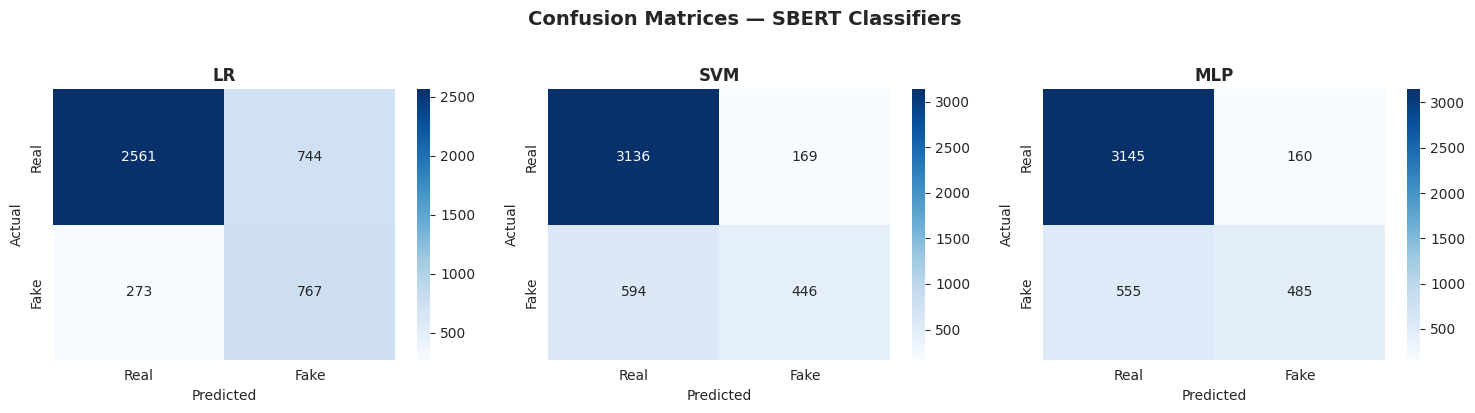

✓ Saved confusion matrices


In [7]:
fig, axes = plt.subplots(1, len(classifiers), figsize=(15, 4))

for ax, (name, clf) in zip(axes, trained_models.items()):
    preds = clf.predict(X_val_emb)
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake']
    )
    ax.set_title(name.replace('SBERT + ', ''), fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — SBERT Classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sbert_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved confusion matrices')

## 6. ROC Curves — SBERT Models

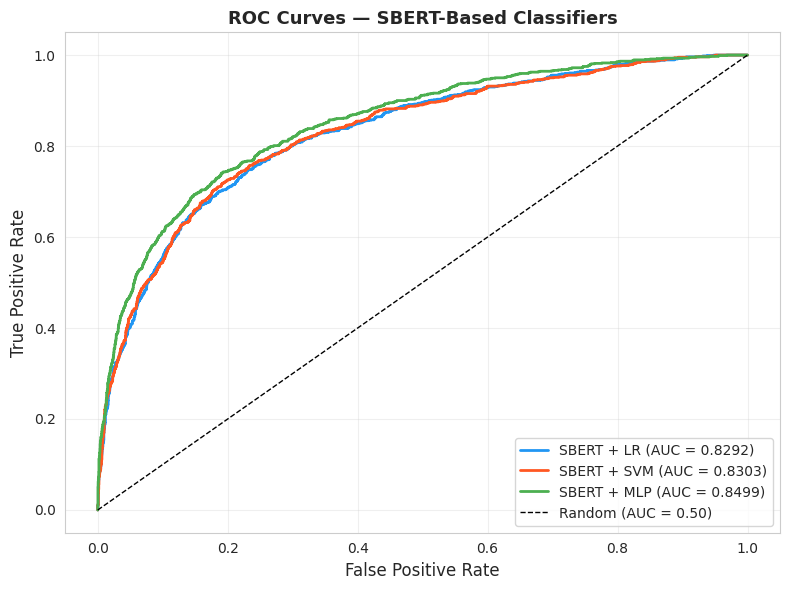

✓ Saved ROC curves


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#FF5722', '#4CAF50']

for (name, clf), color in zip(trained_models.items(), colors):
    proba = clf.predict_proba(X_val_emb)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — SBERT-Based Classifiers', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sbert_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved ROC curves')

## 7. Cross-Validation (Robustness Check)

5-fold stratified CV on the best SBERT classifier to validate that results are stable.

In [9]:
# All embeddings for CV
X_all = np.vstack([X_train_emb, X_val_emb])
y_all = np.concatenate([y_train, y_val])

best_name = max(sbert_results, key=lambda k: sbert_results[k]['roc_auc'])
best_clf  = trained_models[best_name]
# Re-instantiate to avoid data leakage from fitted state
cv_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_clf, X_all, y_all, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV ROC-AUC ({best_name})')
print(f'  Scores : {cv_scores.round(4)}')
print(f'  Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC (SBERT + MLP)
  Scores : [0.8407 0.8239 0.828  0.8198 0.8208]
  Mean   : 0.8267 ± 0.0076


## 8. Optional: DistilBERT Fine-Tuning

Set `RUN_DISTILBERT = True` to fine-tune DistilBERT. Recommended on GPU; runs on CPU but is slow.

In [10]:
RUN_DISTILBERT = False  # Set True to fine-tune (requires transformers + datasets)

distilbert_results = None

if RUN_DISTILBERT:
    try:
        import torch
        from transformers import (
            AutoTokenizer, AutoModelForSequenceClassification,
            TrainingArguments, Trainer, DataCollatorWithPadding
        )
        from datasets import Dataset as HFDataset

        MODEL_NAME = 'distilbert-base-uncased'
        MAX_LEN = 128
        EPOCHS  = 3
        BS      = 16 if DEVICE == 'cuda' else 8

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

        def tokenize(batch):
            return tokenizer(batch['title'], padding='max_length', truncation=True, max_length=MAX_LEN)

        def to_hf_dataset(df_):
            ds = HFDataset.from_dict({'title': df_['title'].tolist(), 'label': df_['label_num'].tolist()})
            return ds.map(tokenize, batched=True, remove_columns=['title'])

        train_hf = to_hf_dataset(train_df)
        val_hf   = to_hf_dataset(val_df)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=-1)
            proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
            return {'accuracy': accuracy_score(labels, preds),
                    'f1': f1_score(labels, preds, average='binary'),
                    'roc_auc': roc_auc_score(labels, proba)}

        model_hf = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

        training_args = TrainingArguments(
            output_dir=str(MODEL_DIR / 'distilbert'),
            num_train_epochs=EPOCHS,
            per_device_train_batch_size=BS,
            per_device_eval_batch_size=BS * 2,
            evaluation_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='roc_auc',
            logging_steps=100,
            seed=42,
            no_cuda=(DEVICE == 'cpu'),
            report_to='none',
        )

        trainer = Trainer(
            model=model_hf,
            args=training_args,
            train_dataset=train_hf,
            eval_dataset=val_hf,
            tokenizer=tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer),
            compute_metrics=compute_metrics,
        )

        t0 = time.time()
        trainer.train()
        distilbert_results = trainer.evaluate()
        distilbert_results['train_time'] = round(time.time() - t0, 1)

        model_hf.save_pretrained(MODEL_DIR / 'distilbert_finetuned')
        tokenizer.save_pretrained(MODEL_DIR / 'distilbert_finetuned')

        print(f'\DistilBERT results: {distilbert_results}')

    except ImportError as e:
        print(f'Skipping DistilBERT: {e}')
        print('Install: pip install transformers datasets torch')
else:
    print('DistilBERT fine-tuning skipped (RUN_DISTILBERT=False)')
    print('To enable: set RUN_DISTILBERT = True in this cell')

DistilBERT fine-tuning skipped (RUN_DISTILBERT=False)
To enable: set RUN_DISTILBERT = True in this cell


## 9. Embedding Space Visualization (PCA)

2D PCA projection of SBERT embeddings, colored by label — shows separability.

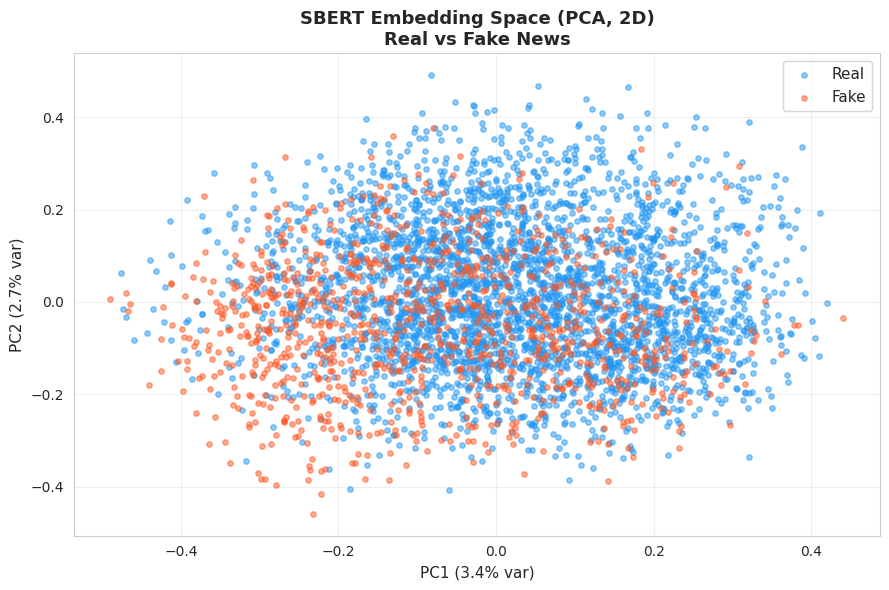

Total variance explained by 2 PCs: 6.2%


In [11]:
from sklearn.decomposition import PCA

# PCA on validation embeddings
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_val_emb)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: '#2196F3', 1: '#FF5722'}
labels_map = {0: 'Real', 1: 'Fake'}

for label_val, color in colors.items():
    mask = y_val == label_val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.5, s=15, label=labels_map[label_val])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=11)
ax.set_title('SBERT Embedding Space (PCA, 2D)\nReal vs Fake News', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sbert_embedding_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')

## 10. Save Models & Results

In [12]:
# Save best SBERT classifier
best_name = max(sbert_results, key=lambda k: sbert_results[k]['roc_auc'])
best_model = trained_models[best_name]

joblib.dump(best_model, MODEL_DIR / 'sbert_best_classifier.joblib')
print(f'✓ Saved best classifier: {best_name}')
print(f'  ROC-AUC: {sbert_results[best_name]["roc_auc"]:.4f}')

# Save all SBERT results
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
summary = {
    'timestamp': ts,
    'device': DEVICE,
    'using_real_data': True,
    'sbert_model': 'all-MiniLM-L6-v2',
    'embedding_dim': int(X_train_emb.shape[1]),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'cv_roc_auc': {'mean': float(cv_scores.mean()), 'std': float(cv_scores.std())},
    'models': sbert_results,
    'distilbert': distilbert_results,
}

out_path = RESULTS_DIR / f'transformer_results_{ts}.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✓ Saved results to {out_path}')

print('\n' + '=' * 60)
print('PHASE 2.3 COMPLETE — TRANSFORMER CLASSIFIERS')
print('=' * 60)
print(f'  Best model : {best_name}')
print(f'  ROC-AUC    : {sbert_results[best_name]["roc_auc"]:.4f}')
print(f'  Accuracy   : {sbert_results[best_name]["accuracy"]:.4f}')
print(f'  5-Fold CV  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Embeddings cached → {EMBEDDING_CACHE}/')
print('Next: 03_error_analysis.ipynb')

✓ Saved best classifier: SBERT + MLP
  ROC-AUC: 0.8499
✓ Saved results to /workspaces/tentacles-of-misinformation/results/transformer_results_20260403_203022.json

PHASE 2.3 COMPLETE — TRANSFORMER CLASSIFIERS
  Best model : SBERT + MLP
  ROC-AUC    : 0.8499
  Accuracy   : 0.8354
  5-Fold CV  : 0.8267 ± 0.0076
Embeddings cached → /workspaces/tentacles-of-misinformation/models/embeddings/
Next: 03_error_analysis.ipynb
